In [61]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [5]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [6]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
360,7274,1957,Graduation,Married,78618.0,0,0,28-09-2012,87,736,...,212,163,61,1,4,7,10,2,0,0
1349,1745,1962,PhD,Divorced,85696.0,0,0,03-05-2013,88,714,...,116,0,12,1,4,6,9,1,0,1
1793,1250,1976,Graduation,Single,37697.0,1,0,07-02-2014,82,34,...,11,4,8,1,2,1,3,6,0,0
257,3406,1964,Graduation,Single,45989.0,0,1,22-10-2012,97,138,...,28,24,12,4,3,2,7,3,0,0
839,5121,1977,Graduation,Single,56628.0,0,1,21-03-2014,30,479,...,7,17,171,2,7,6,5,5,0,0


In [7]:
df["Age"] = 2026 - df["Year_Birth"]

In [8]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
1482,3102,1981,2n Cycle,Together,19414.0,1,0,16-10-2013,32,2,...,5,7,1,1,0,3,8,0,0,45
1972,2452,1971,Graduation,Together,34600.0,1,1,01-01-2013,8,199,...,3,15,5,5,2,5,8,0,1,55
1255,6653,1970,PhD,Married,55158.0,1,1,30-07-2012,72,293,...,11,23,4,7,2,5,7,0,1,56
803,9930,1944,PhD,Single,82716.0,0,0,05-11-2013,8,606,...,148,22,1,6,8,13,2,0,0,82
2128,1631,1965,PhD,Together,65220.0,0,0,03-09-2012,3,890,...,25,12,4,8,4,7,6,0,1,61


In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference = df["Dt_Customer"].max()

df["Tenure"] = (reference - df["Dt_Customer"] ).dt.days

In [10]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure
688,10767,1989,PhD,Together,77845.0,0,0,2014-05-16,40,760,...,26,1,3,5,12,1,0,0,37,44
866,115,1966,Master,Single,43456.0,0,1,2013-03-26,0,275,...,7,3,5,1,8,5,0,0,60,460
1886,7505,1957,PhD,Married,44155.0,1,1,2014-01-19,24,22,...,14,1,1,1,2,4,0,0,69,161
1880,3074,1984,PhD,Married,70643.0,0,0,2012-10-15,66,1218,...,33,1,5,8,4,6,0,1,42,622
1084,6072,1970,Master,Single,75345.0,0,0,2013-02-02,16,918,...,133,1,5,8,6,3,0,1,56,512


In [11]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
Age                    0
Tenure                 0
dtype: int64

In [12]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [13]:
df["Total_child"] = df["Kidhome"] + df["Teenhome"]

In [14]:
df["Education"].value_counts()

# Undergraduate , Graduate , PostGraduate

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [15]:
df["Education"] = df["Education"].map({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate", 
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,Total_Spending,Total_child
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1877,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,30,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,936,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,67,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,511,1


In [17]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [19]:
df["Living_With"] =  df["Marital_Status"].map({
    "Married" : "Together",
    "Together" : "Together", 
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Alone": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [20]:
df["Living_With"].value_counts()

Living_With
Together    1444
Alone        796
Name: count, dtype: int64

In [21]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
Age                    0
Tenure                 0
Total_Spending         0
Total_child            0
Living_With            0
dtype: int64

In [22]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

In [24]:
cols_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_drop)

In [25]:
df_cleaned.shape

(2240, 15)

In [26]:
df.shape

(2240, 27)

In [27]:
df_cleaned.columns


Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age', 'Tenure',
       'Total_Spending', 'Total_child', 'Living_With'],
      dtype='object')

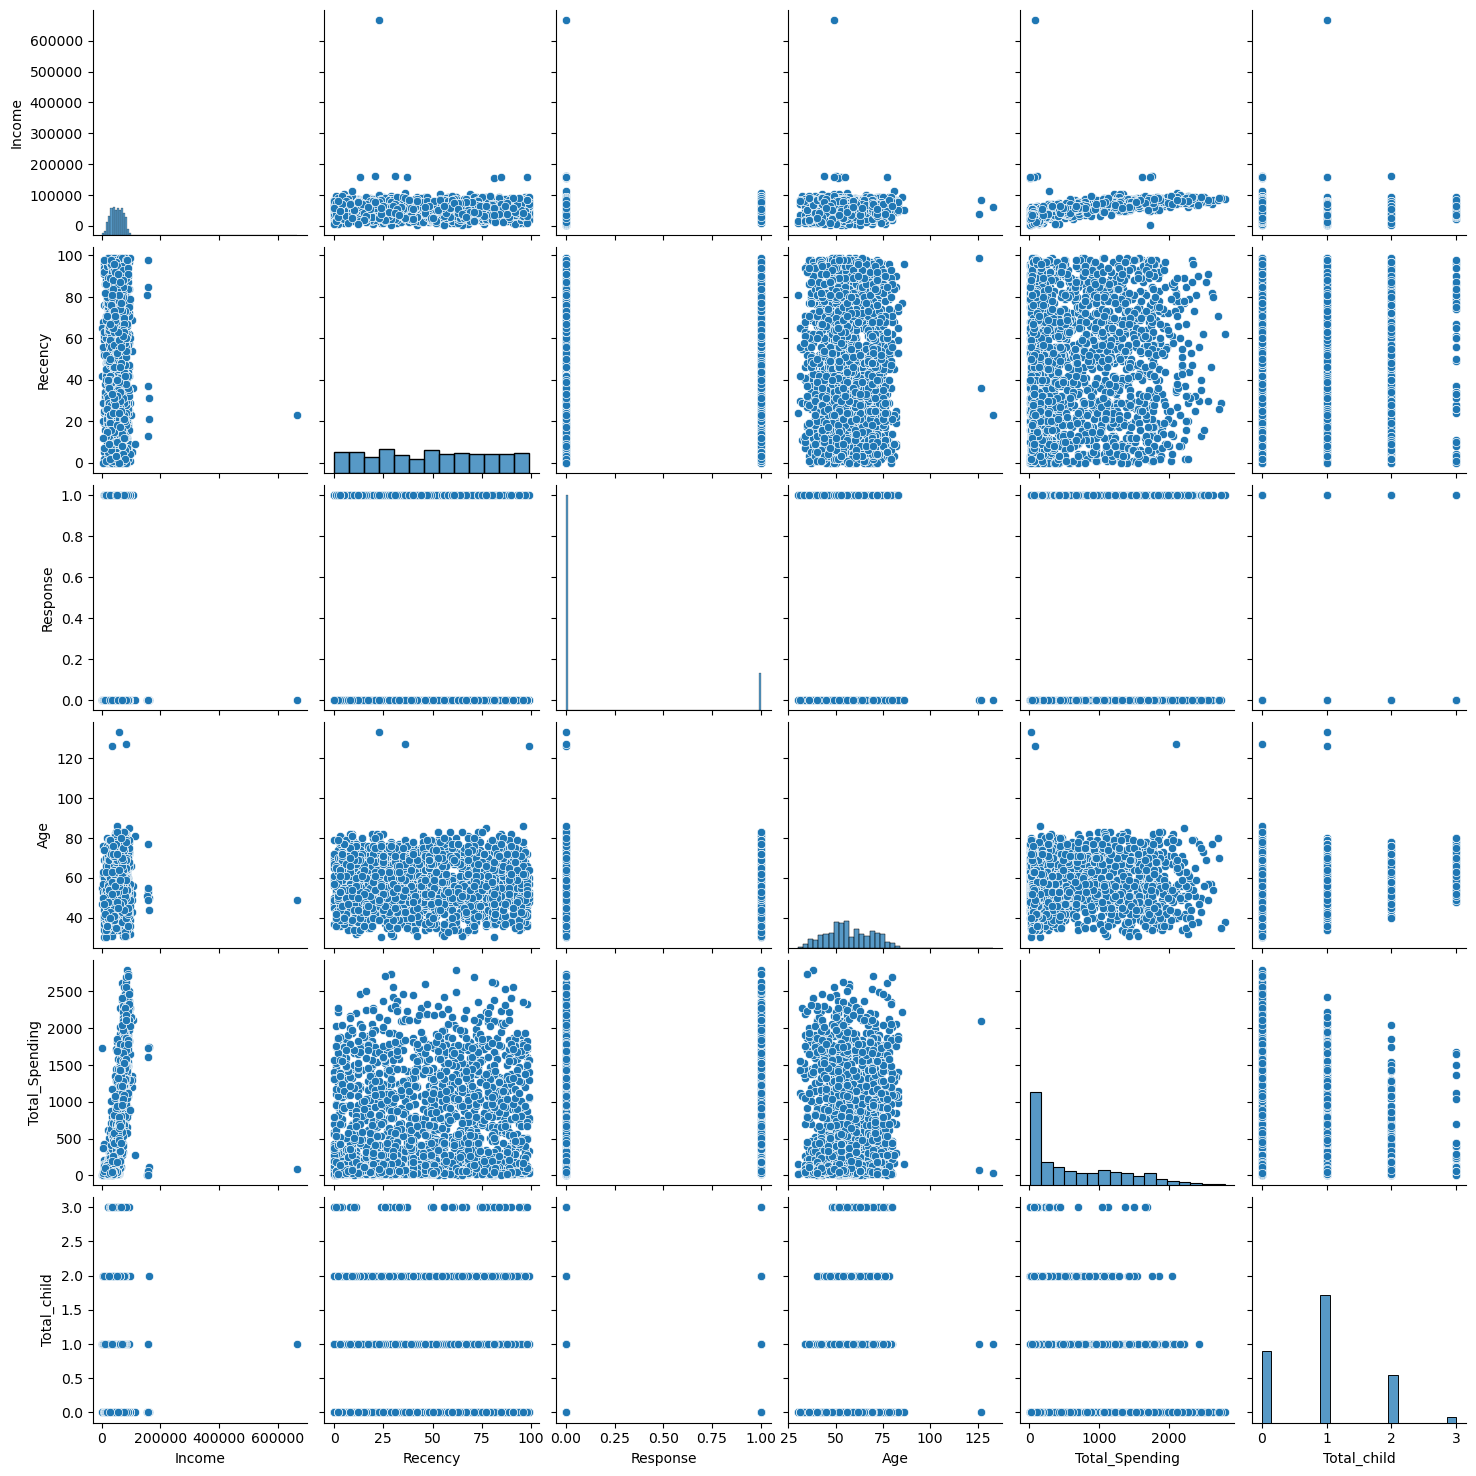

In [29]:
cols = ["Income" , "Recency","Response","Age","Total_Spending","Total_child"]

sns.pairplot(df_cleaned[cols])

In [30]:
df_cleaned = df_cleaned[(df_cleaned['Age']<90)]  
df_cleaned = df_cleaned[(df_cleaned['Income']<600_000)]  

In [31]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

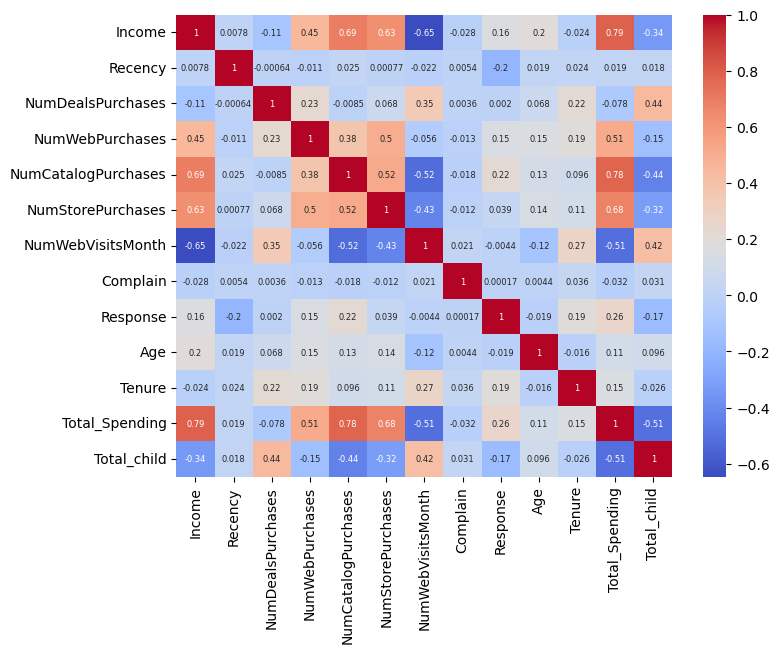

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    annot_kws={"size":6}
)

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [43]:
ohc =OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohc.fit_transform(df_cleaned[cat_cols])

In [44]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohc.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [45]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Together
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [48]:
df_encoded =pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [50]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,Total_Spending,Total_child,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Together
0,58138.0,58,3,8,10,4,7,0,1,69,663,1877,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,30,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,936,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,67,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,511,1,0.0,1.0,0.0,0.0,1.0


In [51]:
df_encoded.shape

(2236, 18)

In [52]:
from sklearn.preprocessing import StandardScaler

In [54]:
x = df_encoded

In [56]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [57]:
x_scaled.shape

(2236, 18)

In [58]:
from sklearn.decomposition import PCA



In [66]:
pca = PCA(n_components=3)

x_pca = pca.fit_transform(x_scaled)

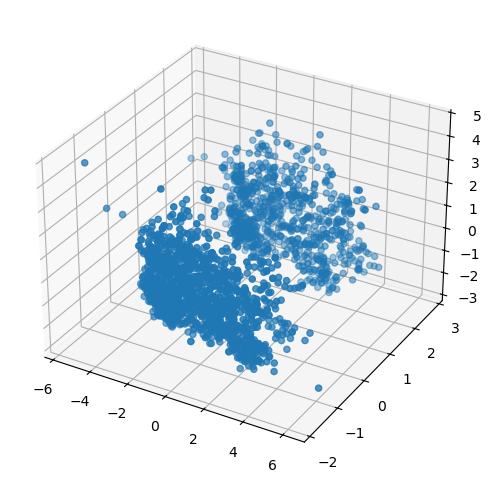

In [67]:

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])


In [71]:

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [73]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

opt_k = knee.elbow

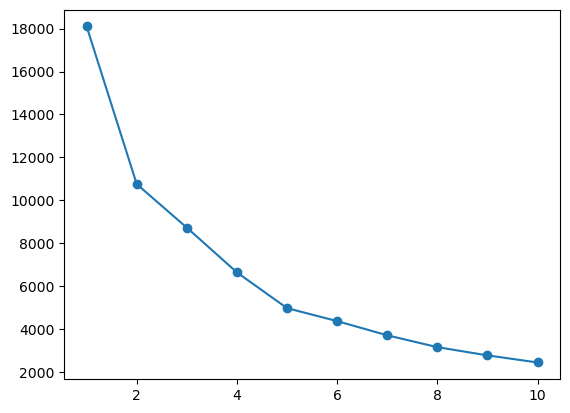

In [74]:
plt.plot(range(1,11),wcss,marker='o')

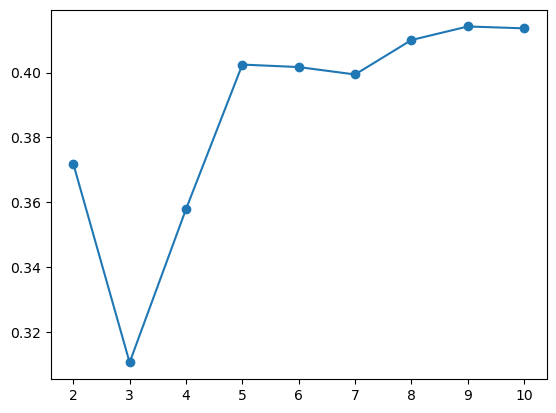

In [80]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11) :
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)


plt.plot(range(2,11),scores,marker='o')

In [83]:
kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

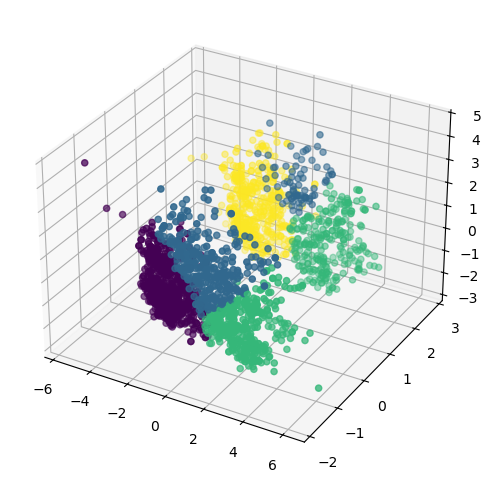

In [84]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [85]:
from sklearn.cluster import AgglomerativeClustering 

In [87]:
agg =AgglomerativeClustering(n_clusters=4,linkage="ward")
labels = agg.fit_predict(x_pca)

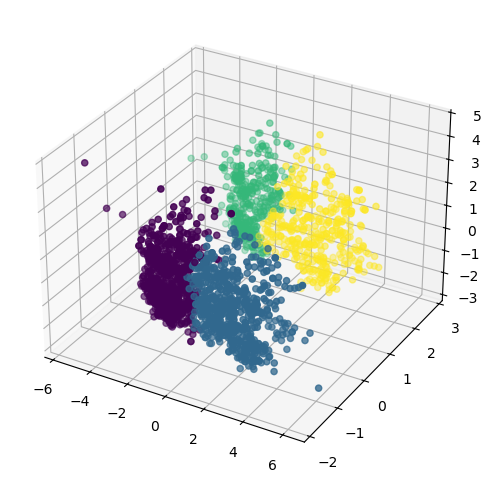

In [88]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

In [89]:
df_cleaned["labels"] = labels

In [90]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Tenure,Total_Spending,Total_child,Living_With,labels
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1877,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,30,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,936,0,Together,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,67,1,Together,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,511,1,Together,0


<Axes: xlabel='labels'>

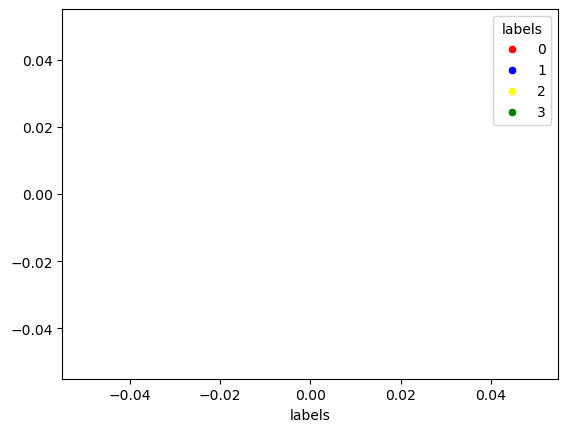

In [91]:
pal = ["red","blue","yellow","green"]

sns.scatterplot(x=df_cleaned["labels"],palette=pal,hue=df_cleaned["labels"])